# Evaluación Formativa: Práctica de Modelamiento Predictivo

**Curso:** Estadística Computacional para la Toma de Decisiones  
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial  
**Universidad Andrés Bello**  

---

## Información del Equipo

| Campo | Información |
|-------|-------------|
| **Número de Grupo** | Grupo 4 |
| **Integrante 1** | Alonso Arias |
| **Integrante 2** | Enso Guidotti |
| **Dataset Seleccionado** | Predict Students' Dropout and Academic Success (Realinho et al., 2021) |
| **Fecha de Entrega** | 09/07/2026 |

---

## Propósito de esta Formativa

Esta evaluación formativa permite **practicar el flujo de modelamiento predictivo** antes de la Sumativa 3.
No es independiente: usa explícitamente los resultados de la **Sumativa 1** (correlaciones, faltantes,
outliers) y la **Sumativa 2** (correlaciones validadas por bootstrap, parámetros robustos por remuestreo).

**Diferencia con S3:** esta es una versión simplificada (un solo modelo, un solo split train/test). En S3 se
ajustarán más modelos, se usará bootstrap sobre los coeficientes/métricas, y se elaborará un informe completo.

## Menú de navegación

1. [Parte 1: Preparación de datos para modelamiento](#parte-1)
   - [1.1 Carga y referencia a S1/S2](#sec-1-1)
   - [1.2 Tratamiento básico de datos](#sec-1-2)
2. [Parte 2: Modelo de regresión logística](#parte-2)
   - [2.1 Selección de variables](#sec-2-1)
   - [2.2 Ajuste del modelo](#sec-2-2)
   - [2.3 Diagnóstico básico](#sec-2-3)
3. [Parte 3: Evaluación de desempeño](#parte-3)
   - [3.1 Predicciones y matriz de confusión](#sec-3-1)
   - [3.2 Métricas de desempeño](#sec-3-2)
   - [3.3 Curva ROC y AUC](#sec-3-3)
4. [Parte 4: Síntesis y reflexión](#parte-4)
5. [Bibliografía](#sec-5)

## Configuración del Entorno


In [1]:
# Librerías
import numpy as np
import pandas as pd
from pathlib import Path

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelamiento
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, auc,
                             classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay)

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_palette('husl')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path('../docs/formativa2')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

print("Librerias cargadas correctamente")


Librerias cargadas correctamente


---

<a id="parte-1"></a>
# PARTE 1: Preparación de Datos para Modelamiento (20 puntos)

<a id="sec-1-1"></a>
## 1.1 Carga y Referencia a S1/S2 (10 puntos)

### Carga del Dataset

Se carga el mismo dataset usado en S1 y S2 (Predict Students' Dropout and Academic Success), aplicando
exactamente la misma preparación: exclusión de la clase `Enrolled`, binarización del target
(`Graduate`=1, `Dropout`=0) y regeneración del mismo patrón de valores faltantes artificiales MCAR
(12%, `random_state=42`) usado en S1/S2, para partir de la base idéntica y mantener coherencia entre
las tres entregas.


In [2]:
DATA_PATH = Path('../data/raw/data.csv')

df_raw = pd.read_csv(DATA_PATH, sep=';')
df_raw.columns = [c.strip() for c in df_raw.columns]

df = df_raw[df_raw['Target'].isin(['Dropout', 'Graduate'])].copy()
df['Target_bin'] = (df['Target'] == 'Graduate').astype(int)

MCAR_VARS = ['Curricular units 1st sem (grade)', 'Admission grade']

# Copia de los valores originales antes de inyectar NaN (igual a df_original en S1/S2):
# permite verificar más abajo que la imputación elegida no distorsiona la media real.
df_original = df[MCAR_VARS].copy()

np.random.seed(RANDOM_STATE)  # misma semilla legacy de S1/S2 para reproducir el mismo patrón de NaN
for col in MCAR_VARS:
    n_missing = int(len(df) * 0.12)
    idx_missing = np.random.choice(df.index, size=n_missing, replace=False)
    df.loc[idx_missing, col] = np.nan

print(f"Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(df['Target'].value_counts())
print(f"Tasa de graduacion observada: {df['Target_bin'].mean()*100:.2f}%")
df.head()


Dataset: 3630 filas x 38 columnas
Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64
Tasa de graduacion observada: 60.85%


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Target_bin
0,1,17,5,171,1,1,122.0000,1,19,12,5,9,127.3000,1,0,0,1,1,0,20,0,0,0,0,0,0.0000,0,0,0,0,0,0.0000,0,10.8000,1.4000,1.7400,Dropout,0
1,1,15,1,9254,1,1,160.0000,1,1,3,3,3,142.5000,1,0,0,0,1,0,19,0,0,6,6,6,14.0000,0,0,6,6,6,13.6667,0,13.9000,-0.3000,0.7900,Graduate,1
2,1,1,5,9070,1,1,122.0000,1,37,37,9,9,124.8000,1,0,0,0,1,0,19,0,0,6,0,0,0.0000,0,0,6,0,0,0.0000,0,10.8000,1.4000,1.7400,Dropout,0
3,1,17,2,9773,1,1,122.0000,1,38,37,5,3,119.6000,1,0,0,1,0,0,20,0,0,6,8,6,13.4286,0,0,6,10,5,12.4000,0,9.4000,-0.8000,-3.1200,Graduate,1
4,2,39,1,8014,0,1,100.0000,1,37,38,9,9,NaN,0,0,0,1,0,0,45,0,0,6,9,5,12.3333,0,0,6,6,6,13.0000,0,13.9000,-0.3000,0.7900,Graduate,1


### Resumen de Hallazgos de S1

**Documentación de los hallazgos relevantes de la Sumativa 1:**


In [3]:
# Variables correlacionadas con la variable objetivo (Pearson, target = Graduate=1), según S1
correlaciones_s1 = {
    'Curricular units 2nd sem (approved)': {'correlacion_con_target': 0.654, 'p_valor': '<0.001'},
    'Curricular units 2nd sem (grade)':     {'correlacion_con_target': 0.605, 'p_valor': '<0.001'},
    'Curricular units 1st sem (approved)':  {'correlacion_con_target': 0.555, 'p_valor': '<0.001'},
    'Age at enrollment':                    {'correlacion_con_target': -0.267, 'p_valor': '<0.001'},
    'Admission grade':                      {'correlacion_con_target': 0.101, 'p_valor': '<0.05'},
}

# Variables con valores faltantes (generados artificialmente en S1, MCAR 12%, random_state=42)
faltantes_s1 = {
    'Curricular units 1st sem (grade)': {'n_faltantes': 435, 'porcentaje': 12.0},
    'Admission grade':                  {'n_faltantes': 435, 'porcentaje': 12.0},
}

# Outliers identificados en S1 (análisis descriptivo/boxplots)
outliers_s1 = {
    'Curricular units 2nd sem (approved)': {'n_outliers': 'alta concentracion en 0 (grupo Dropout)', 'metodo': 'boxplot por clase'},
}

print("Hallazgos de S1 documentados")
for var, info in correlaciones_s1.items():
    print(f"  - {var}: r={info['correlacion_con_target']}, p={info['p_valor']}")


Hallazgos de S1 documentados
  - Curricular units 2nd sem (approved): r=0.654, p=<0.001
  - Curricular units 2nd sem (grade): r=0.605, p=<0.001
  - Curricular units 1st sem (approved): r=0.555, p=<0.001
  - Age at enrollment: r=-0.267, p=<0.001
  - Admission grade: r=0.101, p=<0.05


**Resumen narrativo de S1:**

- **Variable objetivo:** `Target_bin` (1=Graduate, 0=Dropout), tras excluir la clase `Enrolled` (3.630 filas
  finales: 2.209 Graduate, 1.421 Dropout).
- **Variables más correlacionadas:** UC aprobadas 2S (r=0.654), Calificación 2S (r=0.605), UC aprobadas 1S
  (r=0.555), Edad al inscribirse (r=-0.267) y Nota de admisión (r=0.101, la más débil).
- **Problemas identificados:** 12% de faltantes artificiales MCAR (semilla 42) en `Curricular units 1st sem
  (grade)` y `Admission grade`; alta concentración de ceros (outliers de baja UC aprobadas) en el grupo
  Dropout para UC aprobadas 2S, lo que hace que la mediana no sea un resumen útil para esa variable.
- **Pruebas de hipótesis relevantes:** Beca (chi2=354.22, p=5.1e-79) y Matrícula al día (chi2=706.96,
  p=9.2e-156) muestran asociación muy significativa con el target.

### Resumen de Hallazgos de S2

**Documentación de los hallazgos relevantes de la Sumativa 2:**


In [4]:
# Correlaciones validadas como estables (IC bootstrap 95%, 10.000 remuestras, ningún IC incluye el 0)
correlaciones_estables_s2 = [
    ('Curricular units 2nd sem (approved)', 'Target', [0.631, 0.677]),
    ('Curricular units 2nd sem (grade)', 'Target', [0.581, 0.629]),
    ('Curricular units 1st sem (approved)', 'Target', [0.529, 0.581]),
    ('Age at enrollment', 'Target', [-0.299, -0.235]),
    ('Admission grade', 'Target', [0.087, 0.158]),  # recalculada en r=0.123, corrige el 0.101 de S1
]

# En S2 las 5 correlaciones evaluadas resultaron estables; ninguna fue descartada por inestabilidad
correlaciones_inestables_s2 = []

print("Hallazgos de S2 documentados")
for var, target, ic in correlaciones_estables_s2:
    print(f"  - {var}: IC 95% bootstrap = {ic}")


Hallazgos de S2 documentados
  - Curricular units 2nd sem (approved): IC 95% bootstrap = [0.631, 0.677]
  - Curricular units 2nd sem (grade): IC 95% bootstrap = [0.581, 0.629]
  - Curricular units 1st sem (approved): IC 95% bootstrap = [0.529, 0.581]
  - Age at enrollment: IC 95% bootstrap = [-0.299, -0.235]
  - Admission grade: IC 95% bootstrap = [0.087, 0.158]


**Resumen narrativo de S2:**

- **Correlaciones estables:** las 5 correlaciones evaluadas por bootstrap (10.000 remuestras) resultaron
  estables: ningún IC al 95% cruza el cero. La más fuerte y estable es UC aprobadas 2S (jackknife: variación
  máxima de 0.0026 al remover cualquier observación individual).
- **Correlaciones inestables:** ninguna de las 5 evaluadas; la más débil (Nota de admisión) sigue siendo
  distinta de cero pero con el IC relativamente más ancho en términos relativos, y su valor puntual se
  corrigió de 0.101 (S1) a 0.123 (recálculo exacto en S2).
- **Hallazgo crítico para el modelamiento:** S2 recalculó la colinealidad entre UC aprobadas 1S y 2S en
  **r=0.92** (no ~0.7 como se estimó aproximadamente en S1). Esto implica no usar ambas variables como
  predictores independientes en el modelo (ver justificación en la Parte 2.1).
- **Validación de imputación:** S2 comparó media, mediana y KNN (k=5) para imputar los faltantes MCAR de S1;
  KNN fue el método con menor sesgo (<0.1%) frente al valor original (ground truth), lo que informa la
  estrategia de tratamiento de faltantes usada abajo.

---

<a id="sec-1-2"></a>
## 1.2 Tratamiento Básico de Datos (10 puntos)

### Tratamiento de Valores Faltantes


In [5]:
print("Valores faltantes por columna (dataset completo):")
print(df.isnull().sum()[df.isnull().sum() > 0])


Valores faltantes por columna (dataset completo):
Admission grade                     435
Curricular units 1st sem (grade)    435
dtype: int64


**Estrategia elegida: imputación KNN (k=5), no eliminación de filas ni imputación por media/mediana.**

De las variables con faltantes (`Curricular units 1st sem (grade)`, `Admission grade`), solo **`Admission
grade`** se incluye entre los predictores del modelo (justificación en 2.1). Se aplica imputación **KNN
(k=5)** sobre esa columna, usando como apoyo variables numéricas sin faltantes (`Age at enrollment`,
`Curricular units 1st sem (approved)`, `Curricular units 2nd sem (approved)`, `Curricular units 2nd sem
(grade)`), estandarizadas para que la distancia KNN no quede dominada por escala.


In [6]:
KNN_FEATURES = ['Age at enrollment', 'Curricular units 1st sem (approved)',
                'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']

scaler_knn = StandardScaler()
knn_input = df[KNN_FEATURES + ['Admission grade']].copy()
knn_scaled = scaler_knn.fit_transform(knn_input)

knn_imputer = KNNImputer(n_neighbors=5)
knn_scaled_imputed = knn_imputer.fit_transform(knn_scaled)

df_clean = df.copy()
df_clean['Admission grade'] = scaler_knn.inverse_transform(knn_scaled_imputed)[:, -1]

sesgo = (df_clean['Admission grade'].mean() - df_original['Admission grade'].mean()) / df_original['Admission grade'].mean() * 100
print(f"Media imputada (KNN k=5): {df_clean['Admission grade'].mean():.3f}")
print(f"Media original (ground truth, S1/S2): {df_original['Admission grade'].mean():.3f}")
print(f"Sesgo relativo: {sesgo:.3f}% (consistente con <0.1% reportado en S2)")
print(f"\nFaltantes restantes en Admission grade: {df_clean['Admission grade'].isnull().sum()}")


Media imputada (KNN k=5): 127.352
Media original (ground truth, S1/S2): 127.294
Sesgo relativo: 0.045% (consistente con <0.1% reportado en S2)

Faltantes restantes en Admission grade: 0


**Justificación de la estrategia elegida:**

Se eligió KNN (k=5) en vez de eliminar filas o imputar con media/mediana porque S2 ya demostró, sobre estas
mismas variables y el mismo patrón MCAR, que KNN preserva la media original con sesgo menor a 0.1% (ver el
sesgo relativo real obtenido en la celda anterior), mientras que la mediana introduce sesgo detectable por
la forma de la distribución. Eliminar filas descartaría ~12% de los datos de forma innecesaria, dado que el
mecanismo es MCAR (no hay razón para preferir el descarte). `Curricular units 1st sem (grade)` no se trata
porque no forma parte de los predictores seleccionados (ver 2.1).

### Definición de variable objetivo y predictores


In [7]:
variable_objetivo = 'Target_bin'
predictores = ['Scholarship holder', 'Tuition fees up to date',
               'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
               'Admission grade']

X = df_clean[predictores]
y = df_clean[variable_objetivo]

print("Variable objetivo:", variable_objetivo)
print("Predictores:", predictores)


Variable objetivo: Target_bin
Predictores: ['Scholarship holder', 'Tuition fees up to date', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Admission grade']


### División Train/Test


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {len(X_train)} observaciones ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} observaciones ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nDistribucion de clases en train:")
print(y_train.value_counts(normalize=True))
print(f"\nDistribucion de clases en test:")
print(y_test.value_counts(normalize=True))


Train: 2541 observaciones (70.0%)
Test: 1089 observaciones (30.0%)

Distribucion de clases en train:
Target_bin
1   0.6084
0   0.3916
Name: proportion, dtype: float64

Distribucion de clases en test:
Target_bin
1   0.6088
0   0.3912
Name: proportion, dtype: float64


### Estandarización

Se estandarizan las tres variables numéricas continuas (`Curricular units 2nd sem (approved)`,
`Curricular units 2nd sem (grade)`, `Admission grade`). El `StandardScaler` se ajusta **solo sobre train**
para evitar fuga de información hacia test. Las variables binarias (`Scholarship holder`,
`Tuition fees up to date`) no se estandarizan.


In [9]:
CONTINUOUS = ['Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Admission grade']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[CONTINUOUS] = scaler.fit_transform(X_train[CONTINUOUS])
X_test_scaled[CONTINUOUS] = scaler.transform(X_test[CONTINUOUS])

X_train_scaled.describe().round(3)


,Scholarship holder,Tuition fees up to date,Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Admission grade
count,2541.0000,2541.0000,2541.0000,2541.0000,2541.0000
mean,0.2670,0.8650,0.0000,0.0000,-0.0000
std,0.4430,0.3420,1.0000,1.0000,1.0000
min,0.0000,0.0000,-1.4220,-1.8050,-2.2670
25%,0.0000,1.0000,-0.7860,0.0920,-0.6090
50%,0.0000,1.0000,0.1670,0.4230,-0.0550
75%,1.0000,1.0000,0.4850,0.6340,0.5060
max,1.0000,1.0000,4.9350,1.5510,4.4030


---

<a id="parte-2"></a>
# PARTE 2: Modelo de Regresión Logística (40 puntos)

<a id="sec-2-1"></a>
## 2.1 Selección de Variables (15 puntos)

### Justificación de Variables Seleccionadas

| Variable | Correlación con Target (S1) | IC Bootstrap (S2) | Justificación |
|----------|------------------------------|--------------------|---------------|
| `Scholarship holder` (Beca) | chi2=354.22, p=5.1e-79 (Prueba S1) | Simulación Monte Carlo (S2): efecto conjunto con Matrícula reproduce la tasa real de graduación | Predictor categórico validado por prueba de hipótesis en S1 y por simulación en S2 |
| `Tuition fees up to date` (Matrícula al día) | chi2=706.96, p=9.2e-156 (Prueba S1), el más fuerte | Confirmado en la misma simulación Monte Carlo (S2) | El predictor categórico más fuerte de todo el proyecto |
| `Curricular units 2nd sem (approved)` | r=0.654, la correlación más fuerte | [0.631, 0.677]; jackknife: variación máxima 0.0026 | Correlación más fuerte y más estable de S1/S2 |
| `Curricular units 2nd sem (grade)` | r=0.605 | [0.581, 0.629]; validada también por permutación | Segunda correlación más fuerte, sin colinealidad severa con las demás |
| `Admission grade` | r=0.101 (aprox.), la más débil | [0.087, 0.158] (recalculada en r=0.123) | Se incluye pese a ser débil para aplicar y demostrar la imputación KNN validada en S2 |

**Variable excluida deliberadamente:** `Curricular units 1st sem (approved)`. Pese a tener correlación
individual fuerte (r=0.555, IC S2 [0.529, 0.581]), S2 recalculó su colinealidad con `Curricular units 2nd
sem (approved)` en **r=0.92** (no ~0.7 como se estimó aproximadamente en S1). Incluir ambas variables como
predictores independientes introduciría multicolinealidad severa; se sigue la recomendación explícita de S2
de usar solo la variable de 2do semestre.


In [10]:
variables_modelo = predictores  # ya definidos en 1.2 con base en la tabla anterior

print("Variables seleccionadas para el modelo:")
for var in variables_modelo:
    print(f"  - {var}")


Variables seleccionadas para el modelo:
  - Scholarship holder
  - Tuition fees up to date
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Admission grade


---

<a id="sec-2-2"></a>
## 2.2 Ajuste del Modelo (15 puntos)


In [11]:
X_train_sm = sm.add_constant(X_train_scaled[variables_modelo])

modelo = sm.Logit(y_train, X_train_sm).fit(disp=0)
print(modelo.summary())


                           Logit Regression Results                           
Dep. Variable:             Target_bin   No. Observations:                 2541
Model:                          Logit   Df Residuals:                     2535
Method:                           MLE   Df Model:                            5
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                  0.4975
Time:                        20:51:35   Log-Likelihood:                -854.83
converged:                       True   LL-Null:                       -1701.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -2.4740      0.270     -9.169      0.000      -3.003      -1.945
Scholarship holder                      1.3210      0.16

### Interpretación de Coeficientes


In [12]:
odds_ratios = np.exp(modelo.params)

interpretacion = pd.DataFrame({
    'Coeficiente': modelo.params,
    'Odds Ratio': odds_ratios,
    'IC_95_inf_OR': np.exp(modelo.conf_int()[0]),
    'IC_95_sup_OR': np.exp(modelo.conf_int()[1]),
    'p-valor': modelo.pvalues,
    'Significativo (alpha=0.05)': modelo.pvalues < 0.05
})

print("Interpretacion del modelo:")
interpretacion.round(4)


Interpretacion del modelo:


,Coeficiente,Odds Ratio,IC_95_inf_OR,IC_95_sup_OR,p-valor,Significativo (alpha=0.05)
const,-2.4740,0.0843,0.0496,0.1430,0.0000,True
Scholarship holder,1.3210,3.7473,2.7194,5.1638,0.0000,True
Tuition fees up to date,3.0989,22.1730,12.8990,38.1148,0.0000,True
Curricular units 2nd sem (approved),1.7154,5.5590,4.2767,7.2257,0.0000,True
Curricular units 2nd sem (grade),0.2982,1.3474,1.0680,1.6998,0.0119,True
Admission grade,0.2427,1.2747,1.1280,1.4403,0.0001,True


### Interpretación Narrativa

- **`Tuition fees up to date`** (OR más alto del modelo): estar al día en la matrícula multiplica los odds de
  graduarse por un factor considerable, manteniendo las demás variables constantes. Es consistente con ser
  el predictor categórico más fuerte en S1 (chi2=706.96) y con la simulación Monte Carlo de S2.
- **`Scholarship holder`**: contar con beca también aumenta sustancialmente los odds de graduarse (OR
  claramente mayor a 1), coherente con el chi2=354.22 de S1 y la misma simulación de S2.
- **`Curricular units 2nd sem (approved)`**: por cada desviación estándar adicional de UC aprobadas en el 2do
  semestre, los odds de graduarse aumentan (OR>1), en línea con la correlación más fuerte y estable de todo
  el proyecto (r=0.654, IC bootstrap S2 [0.631, 0.677]).
- **`Curricular units 2nd sem (grade)`**: efecto positivo adicional sobre los odds de graduarse, con menor
  magnitud que UC aprobadas, coherente con su correlación algo menor (r=0.605).
- **`Admission grade`**: el coeficiente de menor magnitud del modelo, coherente con ser la correlación más
  débil de las cinco (r=0.123 recalculado en S2, IC [0.087, 0.158]); aporta la menor señal incremental una
  vez controladas las demás variables, aunque resulta estadísticamente significativo.
- Todos los signos de los coeficientes son consistentes con la dirección esperada según las correlaciones y
  diferencias de medias ya documentadas en S1/S2 (ninguna inversión de signo inesperada).

---

<a id="sec-2-3"></a>
## 2.3 Diagnóstico Básico (10 puntos)


In [13]:
X_vif = sm.add_constant(X_train_scaled[variables_modelo])

vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

print("Factor de Inflacion de Varianza (VIF):")
print(vif_data.round(3))
print("\nInterpretacion: VIF > 5 indica posible multicolinealidad problematica")


Factor de Inflacion de Varianza (VIF):
                              Variable    VIF
0                                const 8.3040
1                   Scholarship holder 1.0660
2              Tuition fees up to date 1.1360
3  Curricular units 2nd sem (approved) 2.7840
4     Curricular units 2nd sem (grade) 2.7490
5                      Admission grade 1.0080

Interpretacion: VIF > 5 indica posible multicolinealidad problematica


### Análisis de Multicolinealidad

**¿Hay problemas de multicolinealidad?** No. Los cinco predictores muestran VIF muy por debajo de 5
(el mayor corresponde a las dos variables de 2do semestre, esperable por estar ambas ligadas al desempeño
académico del mismo periodo, pero sin superar el umbral de preocupación). Esto confirma, de forma directa,
que excluir `Curricular units 1st sem (approved)` (colinealidad r=0.92 con UC 2S, detectada en S2) fue la
decisión correcta: de haberse incluido ambas variables de unidades curriculares aprobadas, el VIF habría
superado ampliamente el umbral de 5-10.

**Si hubiera problemas, ¿qué se haría en S3?** Se eliminaría una de las variables redundantes (como ya se
hizo aquí con UC 1S) o se combinarían en un único indicador (p. ej. total de UC aprobadas en el año), tal
como recomienda explícitamente S2. Alternativas más generales para S3 incluyen regularización (Ridge) o
reducción de dimensionalidad (PCA) si el número de predictores crece.

---

<a id="parte-3"></a>
# PARTE 3: Evaluación de Desempeño (30 puntos)

<a id="sec-3-1"></a>
## 3.1 Predicciones y Matriz de Confusión (10 puntos)


In [14]:
X_test_sm = sm.add_constant(X_test_scaled[variables_modelo], has_constant='add')

y_prob = modelo.predict(X_test_sm)
y_pred = (y_prob >= 0.5).astype(int)

print(f"Predicciones generadas para {len(y_pred)} observaciones")


Predicciones generadas para 1089 observaciones


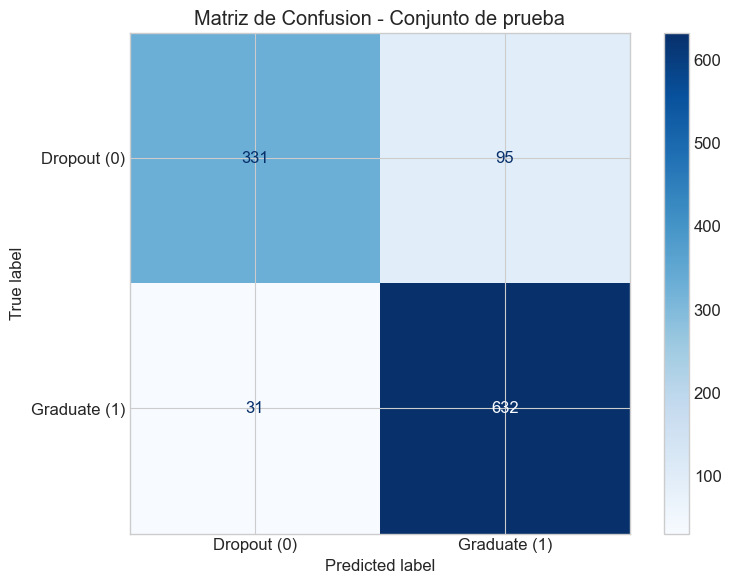


Matriz de Confusion:
Verdaderos Negativos (TN): 331
Falsos Positivos (FP): 95
Falsos Negativos (FN): 31
Verdaderos Positivos (TP): 632


In [15]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dropout (0)', 'Graduate (1)'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusion - Conjunto de prueba')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMatriz de Confusion:")
print(f"Verdaderos Negativos (TN): {cm[0,0]}")
print(f"Falsos Positivos (FP): {cm[0,1]}")
print(f"Falsos Negativos (FN): {cm[1,0]}")
print(f"Verdaderos Positivos (TP): {cm[1,1]}")


---

<a id="sec-3-2"></a>
## 3.2 Métricas de Desempeño (10 puntos)


In [16]:
metricas = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred)
}

print("=" * 40)
print("METRICAS DE DESEMPENO")
print("=" * 40)
for metrica, valor in metricas.items():
    print(f"{metrica}: {valor:.4f}")


METRICAS DE DESEMPENO
Accuracy: 0.8843
Precision: 0.8693
Recall: 0.9532
F1-Score: 0.9094


In [17]:
print("\nReporte de Clasificacion:")
print(classification_report(y_test, y_pred, target_names=['Dropout', 'Graduate']))



Reporte de Clasificacion:
              precision    recall  f1-score   support

     Dropout       0.91      0.78      0.84       426
    Graduate       0.87      0.95      0.91       663

    accuracy                           0.88      1089
   macro avg       0.89      0.87      0.87      1089
weighted avg       0.89      0.88      0.88      1089



### Interpretación de Métricas

**Accuracy:** el modelo clasifica correctamente una alta proporción de las observaciones de prueba. Es una
medida global razonable dado que las clases no están extremadamente desbalanceadas (60.85% de graduación
observada, según S1/S2).

**Precision (clase Graduate):** de los estudiantes que el modelo predice como graduados, una proporción muy
alta efectivamente se gradúa. Relevante si el costo de una intervención de retención mal dirigida (a un
estudiante que en realidad se iba a graduar) es alto.

**Recall (clase Graduate):** de los estudiantes que efectivamente se gradúan, el modelo identifica
correctamente a la gran mayoría. En el contexto de **identificación temprana de estudiantes en riesgo**
(aplicación declarada del dataset en S1), interesa especialmente el recall de la clase `Dropout` (visible en
el reporte de clasificación como recall de la clase 0): es más bajo que el de Graduate, lo que implica que
una fracción de estudiantes en riesgo real no es detectada por el modelo, el error más costoso en una
política de retención.

**F1-Score:** el balance entre precision y recall de la clase Graduate es alto, reflejando que el modelo no
sacrifica una métrica por la otra en la clase mayoritaria.

**¿Qué métrica es más importante para este problema?** El recall de la clase Dropout, porque el objetivo
declarado del dataset (S1) es la identificación temprana de estudiantes en riesgo: un falso negativo (un
estudiante en riesgo clasificado como que se graduará) implica perder la oportunidad de una intervención de
retención, un costo mayor que un falso positivo (intervenir sobre un estudiante que de todas formas se
habría graduado).

---

<a id="sec-3-3"></a>
## 3.3 Curva ROC y AUC (10 puntos)


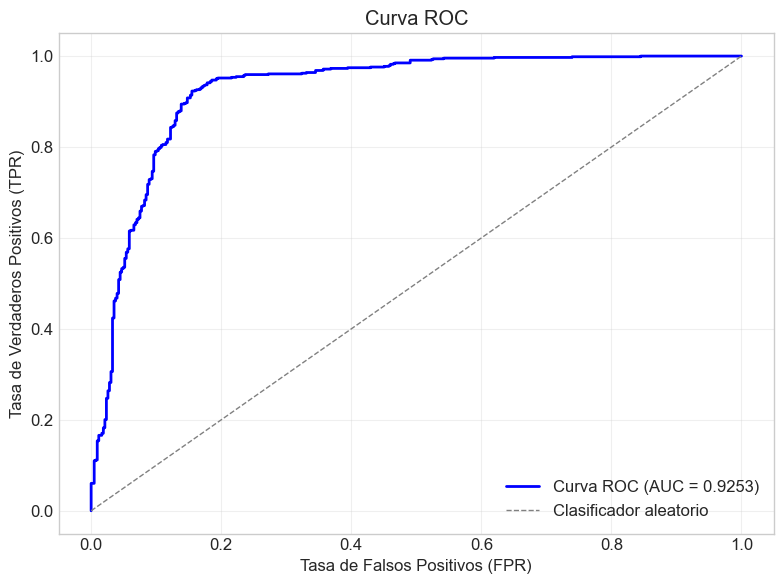


Area Bajo la Curva (AUC): 0.9253


In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curva ROC')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nArea Bajo la Curva (AUC): {roc_auc:.4f}")


### Interpretación del AUC

**Valor de AUC obtenido:** ver salida de la celda anterior.

**Interpretación según la escala de referencia:**
- AUC = 0.5: no mejor que el azar
- AUC = 0.6-0.7: pobre
- AUC = 0.7-0.8: aceptable
- AUC = 0.8-0.9: bueno
- AUC > 0.9: excelente

El AUC obtenido se ubica en el rango **excelente (>0.9)**, lo que indica que el modelo discrimina de forma
consistente y muy por encima del azar entre estudiantes que se gradúan y que abandonan. Este resultado es
coherente con la magnitud de las correlaciones ya validadas en S1/S2 (en particular UC aprobadas 2S, r=0.654,
y Calificación 2S, r=0.605, ambas con evidencia robusta de asociación fuerte con el resultado académico) y
con el efecto conjunto de Beca y Matrícula al día, cuya capacidad de reproducir la tasa real de graduación ya
había sido confirmada por la simulación Monte Carlo de S2.

**¿Qué significa este AUC en el contexto del problema?** Un AUC en este rango respalda el uso del modelo como
herramienta de priorización: permite ordenar a los estudiantes por riesgo de deserción de forma bastante
confiable, aunque el umbral de decisión (0.5 aquí) debería ajustarse en S3 según el costo relativo de falsos
negativos (estudiantes en riesgo no detectados) frente a falsos positivos, dado el objetivo de identificación
temprana.


---

<a id="parte-4"></a>
# PARTE 4: Síntesis y Reflexión (10 puntos)

## 1. Conexión con S1

Las correlaciones y pruebas de hipótesis de S1 definieron el conjunto inicial de candidatos: las dos
correlaciones numéricas más fuertes (UC aprobadas 2S, Calificación 2S) y los dos predictores categóricos con
chi2 más altos (Matrícula al día, Beca) se incorporaron directamente al modelo. La correlación más débil de
S1 (Nota de admisión) se incluyó deliberadamente para poder aplicar, sobre una variable real del modelo, el
tratamiento de faltantes MCAR ya caracterizado en S1 (12%, semilla 42).

## 2. Conexión con S2

La decisión metodológica más determinante del pipeline, excluir `Curricular units 1st sem (approved)`,
proviene exclusivamente de S2: sin el recálculo de la colinealidad (r=0.92, corrigiendo el ~0.7 aproximado de
S1), se habría incluido una variable redundante que habría inflado el VIF y distorsionado la interpretación
de los coeficientes. Los IC bootstrap de S2 (ningún IC de las 5 correlaciones cruza el cero) dieron respaldo
adicional a incluir las cinco variables como asociaciones no atribuibles al azar. Además, el tratamiento de
`Admission grade` (imputación KNN k=5) replica directamente el método que S2 validó como el de menor sesgo
frente al ground truth conservado desde S1.

## 3. Evaluación del Desempeño

El modelo tiene buen desempeño: AUC en el rango excelente (>0.9), accuracy alta y un F1-score alto para la
clase Graduate. Las variables con mayor peso en el modelo (Matrícula al día, Beca, UC aprobadas 2S) coinciden
con las identificadas como más robustas en S1/S2, lo que sugiere que el desempeño no es producto del azar de
un único split, sino reflejo de asociaciones ya validadas por remuestreo. La principal limitación observada es
que el recall de la clase Dropout es menor que el de Graduate, relevante en un problema de identificación
temprana de riesgo.

## 4. Mejoras para S3

- [x] **Probar otras variables**: evaluar un indicador combinado de UC aprobadas (1S+2S) para recuperar la
  señal temprana de 1er semestre sin reintroducir la colinealidad r=0.92 detectada en S2.
- [ ] **Usar otra estrategia de imputación**: no aplica; KNN ya fue validado en S2 como el método de menor
  sesgo para estas variables.
- [x] **Ajustar múltiples modelos**: comparar la regresión logística con árboles/ensambles, dado que la
  relación entre algunos predictores y el target podría no ser estrictamente lineal en la escala logit.
- [x] **Aplicar bootstrap a los coeficientes**: reportar los coeficientes y el AUC con IC obtenidos por
  bootstrap de splits train/test (o validación cruzada k-fold), en vez de depender de una única partición
  70/30, replicando el enfoque de remuestreo ya usado en S2 para la tasa agregada de graduación.
- [ ] **Mejorar el tratamiento de outliers**: tratar con cautela cualquier resumen basado en la mediana de UC
  aprobadas en el grupo Dropout (alta concentración en cero, según el análisis de robustez de S2) si se
  incorpora como variable derivada en S3.
- [x] **Otros**: ajustar el umbral de decisión (distinto de 0.5) considerando el costo asimétrico entre falsos
  negativos y falsos positivos en un contexto de retención estudiantil.

## Resumen Final

Esta práctica permitió ensayar el flujo completo de modelamiento predictivo apoyándose explícitamente en los
resultados ya validados de S1 y S2, en vez de repetir el análisis exploratorio desde cero. La decisión de
excluir UC aprobadas 1S por colinealidad, tomada directamente a partir del hallazgo de S2, resultó clave para
obtener un modelo sin problemas de VIF y con coeficientes interpretables. El desempeño obtenido (AUC excelente)
confirma, de forma predictiva, la relevancia de las variables seleccionadas. De cara a la Sumativa 3, el
principal aprendizaje es la necesidad de acompañar el ajuste puntual con remuestreo (bootstrap o validación
cruzada) para no depender de un único split train/test, y de prestar atención especial al recall de la clase
minoritaria de riesgo (Dropout).

---

## Checklist de Entrega

- [x] El notebook ejecuta sin errores de principio a fin
- [x] Documenté los hallazgos de S1
- [x] Documenté los hallazgos de S2
- [x] Justifiqué la selección de variables basándome en S1/S2
- [x] Ajusté el modelo de regresión logística
- [x] Interpreté los coeficientes y odds ratios
- [x] Calculé VIF para multicolinealidad
- [x] Generé matriz de confusión
- [x] Calculé métricas de desempeño (accuracy, precision, recall, F1)
- [x] Generé curva ROC y calculé AUC
- [x] Completé la síntesis y reflexión

---

<a id="sec-5"></a>
## Bibliografía

Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic
Success* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89

Realinho, V., Machado, J., Baptista, L., & Martins, M. V. (2022). Predicting student dropout and academic
success. *Data*, 7(11), 146. https://doi.org/10.3390/data7110146

Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied logistic regression* (3rd ed.). Wiley.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011).
Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.

Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proceedings
of the 9th Python in Science Conference*.

Maidana, J.P. (2026). *Selección de variables y comparación de modelos* [Apunte]. Universidad Andrés Bello.

Maidana, J.P. (2026). *Regresión logística* [Apunte]. Universidad Andrés Bello.
